<a href="https://colab.research.google.com/github/ncshin/intro-ml-course-winter2026/blob/main/HAD5016H_CP_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## HAD5016H WINTER 2026 - Course Project
### Team 2
#### Urim Iyasere
#### Nathan Shin
#### Vyshnavi Manohara

## Import Libraries

In [ ]:
from google.colab import files
from google.colab import drive

In [ ]:
import pandas as pd
import numpy as np
import warnings
import os
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.metrics import RocCurveDisplay, auc, roc_curve
from sklearn.feature_selection import RFECV

warnings.filterwarnings('ignore')

# Import Data

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import dataset

dir = "/content/drive/My Drive/MPH/MPH/Winter 2026/5016 Machine Learning/HAD5016 Course Project"  # <-- change to your folder

# "/content/drive/My Drive/MPH/MPH/Winter 2026/5016 Machine Learning/HAD5016 Course Project" # Nathan's
# "/content/drive/My Drive/Colab Notebooks/HAD5016/Datathons" => Urim's
# "/content/drive/My Drive/..." => Vy's

filename = "TMU_DM_808K_R1.csv"  # <-- confirm the file name
in_path = os.path.join(dir, filename)

In [ ]:
df = pd.read_csv(in_path)

In [ ]:
df.head()
print(len(df))

808921


In [ ]:
df_cad = df[df['[CAD)'].isin([0, 1])]
df_cad.shape

(102736, 175)

In [ ]:
cols = [
    'Patient_ID', 'sBP_Date', 'Age_at_Exam', 'Sex',
    'LDL', 'LDL_Date',
    'HDL', 'HDL_Date',
    'TG', 'TG_Date',
    'BMI', 'BMI_Date',
    '[Anxiety)', '[Anxiety_Date]',
    '[Depression)', '[Depression_Date]',
    '[CAD)', '[CAD_Date]'
]
# LDL/HDL/TG is probably mmol/L
df_selected = df_cad[cols]

In [ ]:
# Sort df_selected by Patient_ID in ascending order
df_sorted = df_selected.sort_values(by='Patient_ID', ascending=True)

# Print the top 20 entries
# print(df_sorted.head(20))


duplicates = df_selected['Patient_ID'].duplicated().sum()
print(duplicates) # number of duplicates

85546


In [ ]:
df_selected.dtypes

,0
Patient_ID,int64
sBP_Date,object
Age_at_Exam,int64
Sex,object
LDL,float64
LDL_Date,object
HDL,float64
HDL_Date,object
TG,float64
TG_Date,object


In [ ]:
df_selected.shape

(102736, 18)

# Data Preprocessing: Cleaning, EDA, & Feature Engineering

In [ ]:
# Using the map() function to transform the 'Sex' column
df_selected['Sex'] = df_selected['Sex'].map({'Male': 0, 'Female': 1})

In [ ]:
# Ensure the date column is actually a datetime object
df_selected['sBP_Date'] = pd.to_datetime(df_selected['sBP_Date'])

In [ ]:
# Sort by Patient_ID (ascending) and Date (descending)
# This puts the most recent date for each patient at the top
df_sorted = df_selected.sort_values(
    by=['Patient_ID', 'sBP_Date'],
    ascending=[True, False] )

#Drop duplicates, keeping only the first occurrence for each Patient_ID
# Since we sorted descending by date, the 'first' is the most recent
df_most_recent = df_sorted.drop_duplicates(subset='Patient_ID', keep='first')

In [ ]:
df_most_recent.head()

,Patient_ID,sBP_Date,Age_at_Exam,Sex,LDL,LDL_Date,HDL,HDL_Date,TG,TG_Date,BMI,BMI_Date,[Anxiety),[Anxiety_Date],[Depression),[Depression_Date],[CAD),[CAD_Date]
283550,1001000000004140,2007-05-17,63,1,3.12,2007-05-23,2.35,2007-05-23,0.92,2007-05-23,23.422091,2007-05-17,0.0,NaN,0.0,NaN,0.0,NaN
287455,1001000000007276,2008-04-07,51,1,4.05,2008-04-11,1.76,2008-04-11,0.55,2008-04-11,25.200000,2008-04-07,1.0,2012-11-23,1.0,2014-08-28,0.0,NaN
270245,1001000000011757,2013-03-19,46,1,2.14,2013-03-13,1.22,2013-03-13,0.71,2013-03-13,26.400000,2013-03-19,0.0,NaN,0.0,NaN,0.0,NaN
708898,1001000000012561,2014-01-14,74,1,3.43,2013-09-12,0.86,2013-12-17,1.68,2013-12-17,28.800000,2013-09-17,1.0,2009-11-27,0.0,NaN,0.0,NaN
272162,1001000000013745,2006-09-19,40,1,3.98,2006-09-23,1.27,2006-09-23,2.95,2006-09-23,30.000000,2006-01-20,1.0,2013-09-23,1.0,2005-08-16,0.0,NaN


In [ ]:
df_most_recent.shape

(17190, 18)

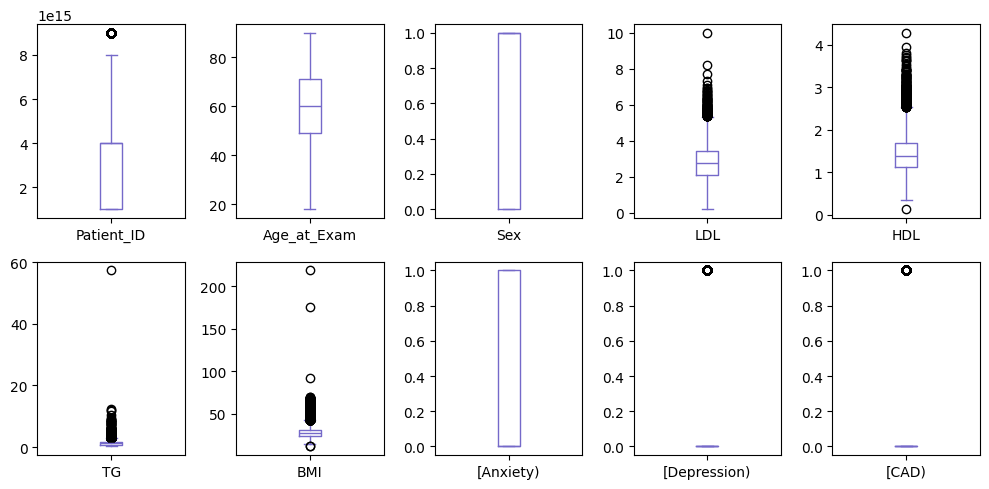

In [ ]:
df_most_recent.plot(kind='box', subplots=True, layout=(2, 5), figsize=(10, 5), color='#7569c9')
plt.tight_layout()
plt.show()

In [ ]:
cols = ['LDL', 'HDL', 'TG', 'BMI']

outlier_counts = {}

for col in cols:
    Q1 = df_most_recent[col].quantile(0.25)
    Q3 = df_most_recent[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_most_recent[(df_most_recent[col] < lower_bound) |
                               (df_most_recent[col] > upper_bound)]

    outlier_counts[col] = len(outliers)

outlier_counts

{'LDL': 123, 'HDL': 310, 'TG': 768, 'BMI': 549}

In [ ]:
df_most_recent.describe()

,Patient_ID,sBP_Date,Age_at_Exam,Sex,LDL,HDL,TG,BMI,[Anxiety),[Depression),[CAD)
count,1.719000e+04,17190,17190.000000,17190.000000,17139.000000,17013.000000,17016.000000,17190.000000,17190.000000,17190.000000,17190.000000
mean,3.255958e+15,2012-11-18 22:01:53.089005312,59.428447,0.638860,2.803839,1.442995,1.376965,28.573179,0.357766,0.219488,0.050204
min,1.001000e+15,2003-11-14 00:00:00,18.000000,0.000000,0.200000,0.130000,0.210000,11.527430,0.000000,0.000000,0.000000
25%,1.003000e+15,2011-09-27 00:00:00,49.000000,0.000000,2.120000,1.130000,0.850000,24.300000,0.000000,0.000000,0.000000
50%,4.001000e+15,2013-05-10 00:00:00,60.000000,1.000000,2.750000,1.380000,1.180000,27.593916,0.000000,0.000000,0.000000
75%,4.001000e+15,2014-07-24 00:00:00,71.000000,1.000000,3.410000,1.690000,1.680000,31.490000,1.000000,0.000000,0.000000
max,9.001000e+15,2015-06-30 00:00:00,90.000000,1.000000,10.000000,4.280000,57.340000,218.700000,1.000000,1.000000,1.000000
std,1.910427e+15,NaN,15.280139,0.480345,0.930343,0.428343,0.898813,6.571702,0.479357,0.413912,0.218371


In [ ]:
df_most_recent = df_most_recent[['Age_at_Exam', 'Sex', 'LDL', 'HDL', 'TG', 'BMI', '[Anxiety)', '[Depression)', '[CAD)']]

In [ ]:
# List of columns that are intended to be dropped from the dataset
dropping_columns = ['Patient_ID', 'LDL_Date', 'HDL_Date', 'TG_Date', 'BMI_Date', '[Anxiety_Date]', '[Depression_Date]', '[CAD_Date]']

# Checking the number of missing values (NaN) in the columns
df_most_recent.isnull().sum()


,0
Age_at_Exam,0
Sex,0
LDL,51
HDL,177
TG,174
BMI,0
[Anxiety),0
[Depression),0
[CAD),0


In [ ]:
print(df_most_recent['LDL'].describe())

count    17139.000000
mean         2.803839
std          0.930343
min          0.200000
25%          2.120000
50%          2.750000
75%          3.410000
max         10.000000
Name: LDL, dtype: float64


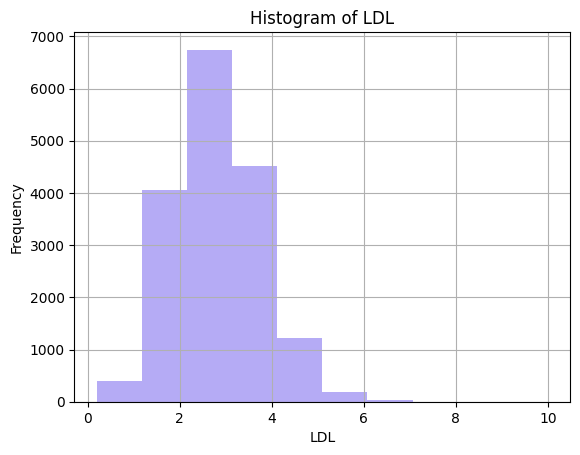

In [ ]:
# Create a histogram for the 'LDL' column with a custom color
df_most_recent['LDL'].hist(color='#b5abf5')  # Using a shade of purple as an example color
plt.xlabel('LDL')  # Label for the x-axis
plt.ylabel('Frequency')     # Label for the y-axis
plt.title('Histogram of LDL')  # Title for the histogram
plt.show()  # Display the histogram

In [ ]:
print(df_most_recent['HDL'].describe())

count    17013.000000
mean         1.442995
std          0.428343
min          0.130000
25%          1.130000
50%          1.380000
75%          1.690000
max          4.280000
Name: HDL, dtype: float64


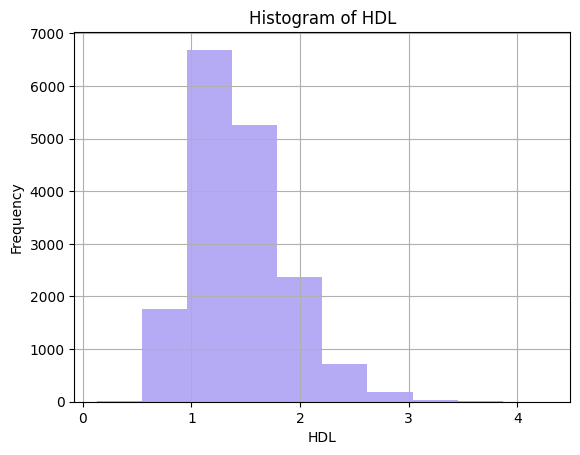

In [ ]:
# Create a histogram for the 'HDL' column with a custom color
df_most_recent['HDL'].hist(color='#b5abf5')  # Using a shade of purple as an example color
plt.xlabel('HDL')  # Label for the x-axis
plt.ylabel('Frequency')     # Label for the y-axis
plt.title('Histogram of HDL')  # Title for the histogram
plt.show()  # Display the histogram

In [ ]:
print(df_most_recent['TG'].describe())

count    17016.000000
mean         1.376965
std          0.898813
min          0.210000
25%          0.850000
50%          1.180000
75%          1.680000
max         57.340000
Name: TG, dtype: float64


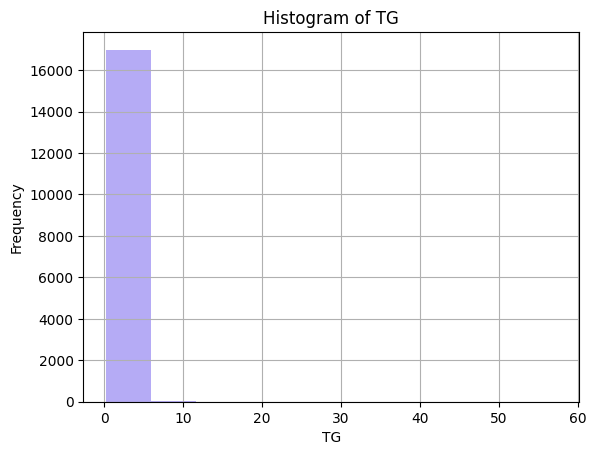

738882    57.34
62991     12.29
551295    12.16
505564    11.64
699066    10.32
776114     9.31
227205     9.26
554629     8.94
401639     8.82
405448     8.81
Name: TG, dtype: float64


In [ ]:
# Create a histogram for the 'TG' column with a custom color
df_most_recent['TG'].hist(color='#b5abf5')  # Using a shade of purple as an example color
plt.xlabel('TG')  # Label for the x-axis
plt.ylabel('Frequency')     # Label for the y-axis
plt.title('Histogram of TG')  # Title for the histogram
plt.show()  # Display the histogram
print(df_most_recent['TG'].nlargest(10))

# Missing Values Assessment

In [ ]:
df_most_recent.isnull().sum()

,0
Age_at_Exam,0
Sex,0
LDL,51
HDL,177
TG,174
BMI,0
[Anxiety),0
[Depression),0
[CAD),0


In [ ]:
# List of unique categories within the 'Sex' column..
missing_Sex = df_most_recent['Sex'].unique()
missing_Sex

array([1, 0])

In [ ]:
# Explore the unique values in the 'Age_at_Exam' column
df_most_recent['Age_at_Exam'].unique()

array([63, 51, 46, 74, 40, 45, 70, 37, 54, 64, 32, 52, 82, 48, 57, 77, 50,
       38, 53, 67, 60, 61, 73, 80, 58, 33, 44, 72, 87, 62, 75, 39, 42, 65,
       78, 29, 71, 34, 55, 41, 49, 47, 19, 83, 68, 22, 66, 84, 79, 43, 28,
       31, 56, 26, 59, 25, 36, 69, 76, 35, 30, 89, 88, 86, 85, 90, 81, 24,
       27, 21, 23, 20, 18])

In [ ]:
# Calculate the percentage of rows with one or more missing values
percentage_missing_rows = (df_most_recent.isnull().sum(axis=1) > 0).sum() / len(df_most_recent)
percentage_missing_rows

np.float64(0.02006980802792321)

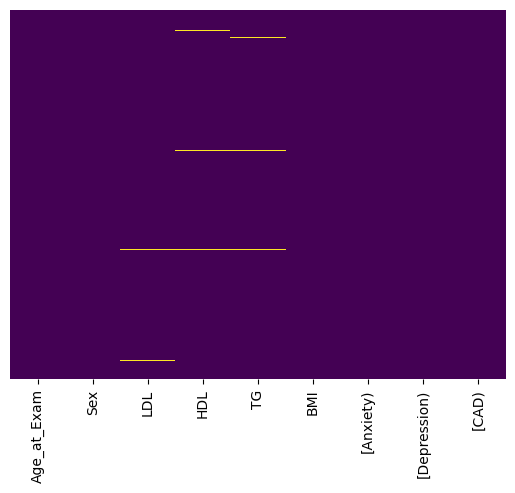

In [ ]:
sns.heatmap(df_most_recent.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.show()

In [ ]:
df_most_recent['is_LDL_na'] = df_most_recent['LDL'].isna().astype(int)

data_male = df_most_recent[df_most_recent['Sex'] == 0]
ldl_cad_tableM = pd.crosstab(data_male['is_LDL_na'], data_male['[CAD)'])
print("\nMale Counts:")
print(ldl_cad_tableM)
print("\nM Row %:")
print(pd.crosstab(data_male['is_LDL_na'], data_male['[CAD)'], normalize='index').round(3))

data_female = df_most_recent[df_most_recent['Sex'] == 1]
ldl_cad_tableF = pd.crosstab(data_female['is_LDL_na'], data_female['[CAD)'])
print("\nFemale Counts:")
print(ldl_cad_tableF)
print("\nF Row %:")
print(pd.crosstab(data_female['is_LDL_na'], data_female['[CAD)'], normalize='index').round(3))

ldl_cad_table = pd.crosstab(df_most_recent['is_LDL_na'], df_most_recent['[CAD)'])
print("\nAll Counts:")
print(ldl_cad_table)
print("\n All Row %:")
print(pd.crosstab(df_most_recent['is_LDL_na'], df_most_recent['[CAD)'], normalize='index').round(3))

del data_male
del data_female
del ldl_cad_tableM
del ldl_cad_tableF
df_most_recent.drop('is_LDL_na', axis=1, inplace=True)


Male Counts:
[CAD)       0.0  1.0
is_LDL_na           
0          5716  464
1            20    8

M Row %:
[CAD)        0.0    1.0
is_LDL_na              
0          0.925  0.075
1          0.714  0.286

Female Counts:
[CAD)        0.0  1.0
is_LDL_na            
0          10569  390
1             22    1

F Row %:
[CAD)        0.0    1.0
is_LDL_na              
0          0.964  0.036
1          0.957  0.043

All Counts:
[CAD)        0.0  1.0
is_LDL_na            
0          16285  854
1             42    9

 All Row %:
[CAD)        0.0    1.0
is_LDL_na              
0          0.950  0.050
1          0.824  0.176


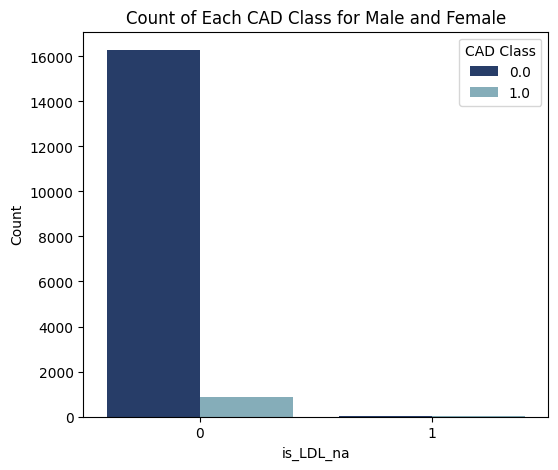

In [ ]:
### Create new variable to denote missingness in LDL
# Create a binary indicator column 'is_[]_na' to represent missing values in the '[]' column
df_most_recent['is_LDL_na'] = df_most_recent['LDL'].isna().astype(int)

### Create plot ------------------------------------------------------------------------------------------------------------------------
# Define a list of colors for the countplot
colors = ['#1c3a73', '#7cb1c2']

# Create a grouped bar chart using seaborn's countplot function with specified colors
plt.figure(figsize=(6, 5))
sns.countplot(data=df_most_recent, x='is_LDL_na', hue='[CAD)', palette=colors)

# Set labels and title for the plot
plt.xlabel('is_LDL_na')
plt.ylabel('Count')
plt.title('Count of Each CAD Class for Male and Female')
plt.legend(title='CAD Class')
plt.show()

# Remove the 'is_LDL_na' column from the DataFrame
df_most_recent.drop('is_LDL_na', axis=1, inplace=True)

In [ ]:
df_most_recent['is_HDL_na'] = df_most_recent['HDL'].isna().astype(int)

data_male = df_most_recent[df_most_recent['Sex'] == 0]
hdl_cad_tableM = pd.crosstab(data_male['is_HDL_na'], data_male['[CAD)'])
print("\nMale Counts:")
print(hdl_cad_tableM)
print("\nM Row %:")
print(pd.crosstab(data_male['is_HDL_na'], data_male['[CAD)'], normalize='index').round(3))

data_female = df_most_recent[df_most_recent['Sex'] == 1]
hdl_cad_tableF = pd.crosstab(data_female['is_HDL_na'], data_female['[CAD)'])
print("\nFemale Counts:")
print(hdl_cad_tableF)
print("\nF Row %:")
print(pd.crosstab(data_female['is_HDL_na'], data_female['[CAD)'], normalize='index').round(3))

hdl_cad_table = pd.crosstab(df_most_recent['is_HDL_na'], df_most_recent['[CAD)'])
print("\nAll Counts:")
print(hdl_cad_table)
print("\n All Row %:")
print(pd.crosstab(df_most_recent['is_HDL_na'], df_most_recent['[CAD)'], normalize='index').round(3))

del data_male
del data_female
del hdl_cad_tableM
del hdl_cad_tableF
df_most_recent.drop('is_HDL_na', axis=1, inplace=True)


Male Counts:
[CAD)       0.0  1.0
is_HDL_na           
0          5676  469
1            60    3

M Row %:
[CAD)        0.0    1.0
is_HDL_na              
0          0.924  0.076
1          0.952  0.048

Female Counts:
[CAD)        0.0  1.0
is_HDL_na            
0          10477  391
1            114    0

F Row %:
[CAD)        0.0    1.0
is_HDL_na              
0          0.964  0.036
1          1.000  0.000

All Counts:
[CAD)        0.0  1.0
is_HDL_na            
0          16153  860
1            174    3

 All Row %:
[CAD)        0.0    1.0
is_HDL_na              
0          0.949  0.051
1          0.983  0.017


In [ ]:
df_most_recent['is_TG_na'] = df_most_recent['TG'].isna().astype(int)

data_male = df_most_recent[df_most_recent['Sex'] == 0]
tg_cad_tableM = pd.crosstab(data_male['is_TG_na'], data_male['[CAD)'])
print("\nMale Counts:")
print(tg_cad_tableM)
print("\nM Row %:")
print(pd.crosstab(data_male['is_TG_na'], data_male['[CAD)'], normalize='index').round(3))

data_female = df_most_recent[df_most_recent['Sex'] == 1]
tg_cad_tableF = pd.crosstab(data_female['is_TG_na'], data_female['[CAD)'])
print("\nFemale Counts:")
print(tg_cad_tableF)
print("\nF Row %:")
print(pd.crosstab(data_female['is_TG_na'], data_female['[CAD)'], normalize='index').round(3))

tg_cad_table = pd.crosstab(df_most_recent['is_TG_na'], df_most_recent['[CAD)'])
print("\nAll Counts:")
print(tg_cad_table)
print("\n All Row %:")
print(pd.crosstab(df_most_recent['is_TG_na'], df_most_recent['[CAD)'], normalize='index').round(3))

del data_male
del data_female
del tg_cad_tableM
del tg_cad_tableF
df_most_recent.drop('is_TG_na', axis=1, inplace=True)


Male Counts:
[CAD)      0.0  1.0
is_TG_na           
0         5697  470
1           39    2

M Row %:
[CAD)       0.0    1.0
is_TG_na              
0         0.924  0.076
1         0.951  0.049

Female Counts:
[CAD)       0.0  1.0
is_TG_na            
0         10459  390
1           132    1

F Row %:
[CAD)       0.0    1.0
is_TG_na              
0         0.964  0.036
1         0.992  0.008

All Counts:
[CAD)       0.0  1.0
is_TG_na            
0         16156  860
1           171    3

 All Row %:
[CAD)       0.0    1.0
is_TG_na              
0         0.949  0.051
1         0.983  0.017


It seems that cholesterol measurements, such as LDL, HDL, & TG levels, may be missing at random (MAR).

In [ ]:
df_most_recent.shape

(17190, 9)

In [ ]:
df_most_recent.isnull().sum()

,0
Age_at_Exam,0
Sex,0
LDL,51
HDL,177
TG,174
BMI,0
[Anxiety),0
[Depression),0
[CAD),0


In [ ]:
df_most_recent.describe()

,Age_at_Exam,Sex,LDL,HDL,TG,BMI,[Anxiety),[Depression),[CAD)
count,17190.000000,17190.000000,17139.000000,17013.000000,17016.000000,17190.000000,17190.000000,17190.000000,17190.000000
mean,59.428447,0.638860,2.803839,1.442995,1.376965,28.573179,0.357766,0.219488,0.050204
std,15.280139,0.480345,0.930343,0.428343,0.898813,6.571702,0.479357,0.413912,0.218371
min,18.000000,0.000000,0.200000,0.130000,0.210000,11.527430,0.000000,0.000000,0.000000
25%,49.000000,0.000000,2.120000,1.130000,0.850000,24.300000,0.000000,0.000000,0.000000
50%,60.000000,1.000000,2.750000,1.380000,1.180000,27.593916,0.000000,0.000000,0.000000
75%,71.000000,1.000000,3.410000,1.690000,1.680000,31.490000,1.000000,0.000000,0.000000
max,90.000000,1.000000,10.000000,4.280000,57.340000,218.700000,1.000000,1.000000,1.000000


In [ ]:
# LDL, HDL, TG, BMI
df_outliers = df_most_recent.copy()
print("Initial rows:", len(df_outliers))
cols = ['LDL', 'HDL', 'TG', 'BMI']

outlier_mask = pd.Series(False, index=df_outliers.index)

for col in cols:
    Q1 = df_outliers[col].quantile(0.25)
    Q3 = df_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    col_outliers = (df_outliers[col] < lower) | (df_outliers[col] > upper)

    # Mark rows that have outliers in ANY column
    outlier_mask = outlier_mask | col_outliers

# 5. Remove rows with any outliers
df_nooutliers = df_outliers[~outlier_mask]

# 6. Print updated number of rows
print("Rows after removing outliers:", len(df_nooutliers))

print("Rows removed:", len(df_outliers) - len(df_nooutliers))

print("Removed percent:", (1 - len(df_nooutliers) / len(df_outliers)) * 100, "%")

Initial rows: 17190
Rows after removing outliers: 16895
Rows removed: 295
Removed percent: 1.716114019778936 %


In [ ]:
df_nooutliers.head()

,Age_at_Exam,Sex,LDL,HDL,TG,BMI,[Anxiety),[Depression),[CAD)
283550,63,1,3.12,2.35,0.92,23.422091,0.0,0.0,0.0
287455,51,1,4.05,1.76,0.55,25.200000,1.0,1.0,0.0
270245,46,1,2.14,1.22,0.71,26.400000,0.0,0.0,0.0
708898,74,1,3.43,0.86,1.68,28.800000,1.0,0.0,0.0
272162,40,1,3.98,1.27,2.95,30.000000,1.0,1.0,0.0


# Assessing Collinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Prepare predictors (exclude target)
X = (
    df_nooutliers
    .drop(columns=['[CAD)'])
    .select_dtypes(include=[np.number])
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# Add constant for VIF calculation
X_const = add_constant(X)

# VIF -  Variance Inflation Factor, measures multicollinearity in regression models
# Compute VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i)
                    for i in range(X_const.shape[1])]

# Display VIF results
print(vif_data)

        feature        VIF
0         const  84.658646
1   Age_at_Exam   1.116200
2           Sex   1.203567
3           LDL   1.070371
4           HDL   1.494735
5            TG   1.294683
6           BMI   1.167318
7     [Anxiety)   1.095892
8  [Depression)   1.074875


In [ ]:
df_final = df_nooutliers

# Model Pipeline

## Class Imbalance

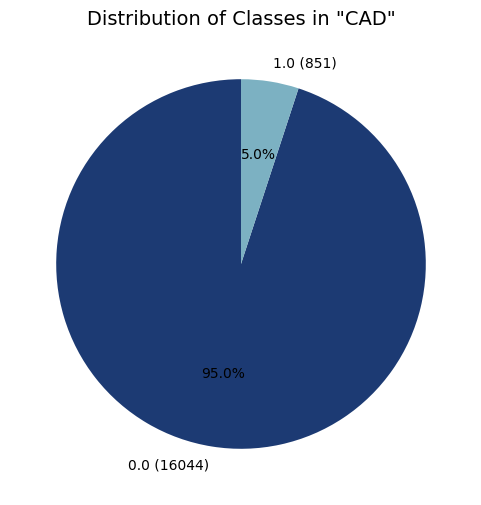

In [ ]:
### Create a pie chart to show the distribution of categories in the 'Class/ASD' variable --------------
# Count occurrences of each class in our variable of interest
counts = df_final['[CAD)'].value_counts()

# Define colors
colors = ['#1c3a73', '#7cb1c2']

# Create pie chart
plt.figure(figsize=(6, 6)) #tuple for fig size, 6x6 inches
plt.pie(
    counts, #counts for each class
    labels=[f'{cls} ({count})' for cls, count in counts.items()],  # add labels with counts... counts.items() returns an iterable of tuples
                                                                    #e.g., [('class', count)], which are then unpacked and formatted into labels
    autopct='%1.1f%%',  # Show percentages
    colors=colors,
    startangle=90
)

# Set title
plt.title('Distribution of Classes in "CAD"', fontsize=14)

# Show plot
plt.show()



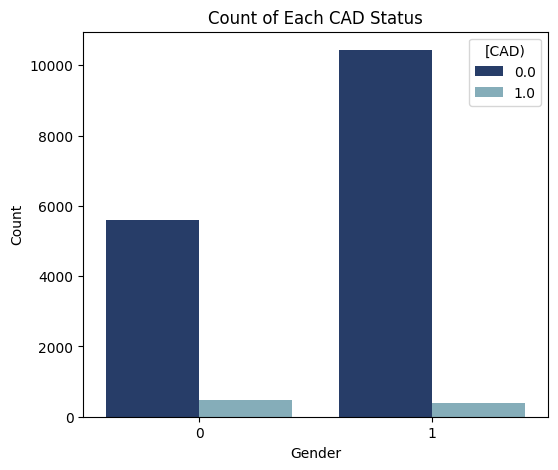

In [ ]:
### Here will will explore the distribution of 'CAD' by Sex
### Create plot
# Define a list of colors
colors = ['#1c3a73', '#7cb1c2']

# Create the grouped bar chart using seaborn's countplot function with specified colors
plt.figure(figsize=(6, 5))
sns.countplot(data=df_final, x='Sex', hue='[CAD)', palette=colors)

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Count of Each CAD Status')
plt.legend(title='[CAD)')
plt.show()


## Split Train and Test

In [ ]:
# Psychological + Clinical + Demographic
x = df_final[['Age_at_Exam', 'Sex', 'LDL', 'HDL', 'TG', 'BMI', '[Anxiety)', '[Depression)']]

y = df_final[['[CAD)']]

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42) # split train/other 80/20

x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42) # split validation/test 50/50

In [ ]:
print("validation: ",x_val.shape,"\n",
      "test: ", x_test.shape, "\n",
      "train: ", x_train.shape)

validation:  (1689, 8) 
 test:  (1690, 8) 
 train:  (13516, 8)


## Imputation (MICE)

In [ ]:
impute_cols = ["LDL", "HDL", "TG"]

# make copies to preserve originals
x_train_orig = x_train.copy()
x_val_orig = x_val.copy()
x_test_orig = x_test.copy()

# fit on training set only
imputer = IterativeImputer(max_iter=10, random_state=42)

x_train[impute_cols] = imputer.fit_transform(x_train[impute_cols])
x_val[impute_cols] = imputer.transform(x_val[impute_cols])
x_test[impute_cols] = imputer.transform(x_test[impute_cols])

In [ ]:
# check
print(x_train.isnull().sum())
print(x_val.isnull().sum())
print(x_test.isnull().sum())

Age_at_Exam     0
Sex             0
LDL             0
HDL             0
TG              0
BMI             0
[Anxiety)       0
[Depression)    0
dtype: int64
Age_at_Exam     0
Sex             0
LDL             0
HDL             0
TG              0
BMI             0
[Anxiety)       0
[Depression)    0
dtype: int64
Age_at_Exam     0
Sex             0
LDL             0
HDL             0
TG              0
BMI             0
[Anxiety)       0
[Depression)    0
dtype: int64


## Logistic Regression

In [ ]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection",
     RFECV(
        estimator=LogisticRegression(penalty='l2', solver='liblinear', random_state=42),
        cv=5,
        scoring='recall',
        min_features_to_select=5
    )),
    ("model", LogisticRegression(penalty='l2', solver='liblinear', random_state=42))
])

lr_grid = {
    "model__C": [0.01, 0.1, 1, 10, 25, 50, 75, 100],
    "model__class_weight": ['balanced']
}

grid_lr = GridSearchCV(lr_pipe, lr_grid, cv=5, scoring='recall')
grid_lr.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('feature_selection',
                                        RFECV(cv=5,
                                              estimator=LogisticRegression(random_state=42,
                                                                           solver='liblinear'),
                                              min_features_to_select=5,
                                              scoring='recall')),
                                       ('model',
                                        LogisticRegression(random_state=42,
                                                           solver='liblinear'))]),
             param_grid={'model__C': [0.01, 0.1, 1, 10, 25, 50, 75, 100],
                         'model__class_weight': ['balanced']},
             scoring='recall')

In [ ]:
lr = grid_lr.best_estimator_

In [ ]:
rfecv = lr.named_steps["feature_selection"]
selected_mask = rfecv.support_
selected_features = x_train.columns[selected_mask]
print(selected_features)
print("Number of selected features:", rfecv.n_features_)
ranking = rfecv.ranking_

feature_ranking = pd.DataFrame({
    "Feature": x_train.columns,
    "Rank": ranking
}).sort_values(by="Rank")

print(feature_ranking)

Index(['Age_at_Exam', 'Sex', 'LDL', 'HDL', '[Depression)'], dtype='object')
Number of selected features: 5
        Feature  Rank
0   Age_at_Exam     1
1           Sex     1
2           LDL     1
3           HDL     1
7  [Depression)     1
4            TG     2
6     [Anxiety)     3
5           BMI     4


In [ ]:
# Training
y_pred = lr.predict(x_train)
print("Training Recall:", recall_score(y_train, y_pred))
print("Training F1:", f1_score(y_train, y_pred))

# Validation
y_pred = lr.predict(x_val)
print("\nValidation Recall:", recall_score(y_val, y_pred))
print("Validation F1:", f1_score(y_val, y_pred))

Training Recall: 0.7611275964391692
Training F1: 0.19761171032357472

Validation Recall: 0.7586206896551724
Validation F1: 0.2015267175572519


## XG Boost

In [ ]:
y_ratio = y_train.squeeze()

neg = (y_ratio == 0).sum()
pos = (y_ratio == 1).sum()

ratio = float(neg / pos)

ratio

19.05341246290801

In [ ]:
xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ("feature_selection",
     RFECV(
        estimator=XGBClassifier(random_state=42, scale_pos_weight=ratio),
        cv=5,
        scoring='recall',
        min_features_to_select=5
    )),
    ('xgb', XGBClassifier(random_state=42, scale_pos_weight=ratio))
])

param_grid_xgb = {
    "xgb__learning_rate": [0.01, 0.1],
    "xgb__max_depth": [3, 6],
    "xgb__n_estimators": [100, 200]
}

param_grid_xgb_alt = {
    "xgb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "xgb__max_depth": [3, 4, 5, 6, 8],
    "xgb__n_estimators": [100, 200, 300, 500]
}

In [ ]:
# Tune XGBoost
grid_xgb = GridSearchCV(xgb_pipe, param_grid_xgb, cv=StratifiedKFold(5), scoring='recall', n_jobs=-1)
grid_xgb.fit(x_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('feature_selection',
                                        RFECV(cv=5,
                                              estimator=XGBClassifier(base_score=None,
                                                                      booster=None,
                                                                      callbacks=None,
                                                                      colsample_bylevel=None,
                                                                      colsample_bynode=None,
                                                                      colsample_bytree=None,
                                                                      device=None,
                                                                      early_stopping_rounds=None,
                                                                      enable_categor...
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__learning_rate': [0.01, 0.1],
                         'xgb__max_depth': [3, 6],
                         'xgb__n_estimators': [100, 200]},
             scoring='recall')

In [ ]:
grid_xgb_alt = GridSearchCV(xgb_pipe, param_grid_xgb_alt, cv=StratifiedKFold(5), scoring='recall', n_jobs=-1)
grid_xgb_alt.fit(x_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('feature_selection',
                                        RFECV(cv=5,
                                              estimator=XGBClassifier(base_score=None,
                                                                      booster=None,
                                                                      callbacks=None,
                                                                      colsample_bylevel=None,
                                                                      colsample_bynode=None,
                                                                      colsample_bytree=None,
                                                                      device=None,
                                                                      early_stopping_rounds=None,
                                                                      enable_categor...
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'xgb__max_depth': [3, 4, 5, 6, 8],
                         'xgb__n_estimators': [100, 200, 300, 500]},
             scoring='recall')

In [ ]:
xgb_alt = grid_xgb_alt.best_estimator_
xgb = grid_xgb.best_estimator_

In [ ]:
rfecv = xgb.named_steps["feature_selection"]
selected_mask = rfecv.support_
selected_features = x_train.columns[selected_mask]
print(selected_features)
print("Number of selected features:", rfecv.n_features_)
ranking = rfecv.ranking_

feature_ranking = pd.DataFrame({
    "Feature": x_train.columns,
    "Rank": ranking
}).sort_values(by="Rank")

print(feature_ranking)

Index(['Age_at_Exam', 'Sex', 'LDL', '[Anxiety)', '[Depression)'], dtype='object')
Number of selected features: 5
        Feature  Rank
0   Age_at_Exam     1
1           Sex     1
2           LDL     1
7  [Depression)     1
6     [Anxiety)     1
3           HDL     2
4            TG     3
5           BMI     4


In [ ]:
rfecv = xgb_alt.named_steps["feature_selection"]
selected_mask = rfecv.support_
selected_features = x_train.columns[selected_mask]
print(selected_features)
print("Number of selected features:", rfecv.n_features_)
ranking = rfecv.ranking_

feature_ranking = pd.DataFrame({
    "Feature": x_train.columns,
    "Rank": ranking
}).sort_values(by="Rank")

print(feature_ranking)

Index(['Age_at_Exam', 'Sex', 'LDL', '[Anxiety)', '[Depression)'], dtype='object')
Number of selected features: 5
        Feature  Rank
0   Age_at_Exam     1
1           Sex     1
2           LDL     1
7  [Depression)     1
6     [Anxiety)     1
3           HDL     2
4            TG     3
5           BMI     4


# Model Selection


In [ ]:
# Compare on the Validation Set

lr_val_f1 = f1_score(y_val, lr.predict(x_val))
lr_val_recall = recall_score(y_val, lr.predict(x_val))
lr_val_auc = roc_auc_score(y_val, lr.predict_proba(x_val)[:, 1])

xgb_val_f1 = f1_score(y_val, xgb.predict(x_val))
xgb_val_recall = recall_score(y_val, xgb.predict(x_val))
xgb_val_auc = roc_auc_score(y_val, xgb.predict_proba(x_val)[:, 1])

xgb_val_f1_alt = f1_score(y_val, xgb_alt.predict(x_val))
xgb_val_recall_alt = recall_score(y_val, xgb_alt.predict(x_val))
xgb_val_auc_alt = roc_auc_score(y_val, xgb_alt.predict_proba(x_val)[:, 1])

print(f"--- VALIDATION RESULTS ---")
print(f"Logistic Regression F1: {lr_val_f1:.4f}")
print(f"Logistic Regression Recall: {lr_val_recall:.4f}")
print(f"Logistic Regression AUC: {lr_val_auc:.4f}")

print(f"--------------------------")
print(f"XGBoost F1: {xgb_val_f1:.4f}")
print(f"XGBoost Recall: {xgb_val_recall:.4f}")
print(f"XGBoost AUC: {xgb_val_auc:.4f}")

print(f"--------------------------")
print(f"XGBoost F1 Alt: {xgb_val_f1_alt:.4f}")
print(f"XGBoost Recall Alt: {xgb_val_recall_alt:.4f}")
print(f"XGBoost AUC Alt: {xgb_val_auc_alt:.4f}")

--- VALIDATION RESULTS ---
Logistic Regression F1: 0.2015
Logistic Regression Recall: 0.7586
Logistic Regression AUC: 0.7898
--------------------------
XGBoost F1: 0.1920
XGBoost Recall: 0.8046
XGBoost AUC: 0.8068
--------------------------
XGBoost F1 Alt: 0.1929
XGBoost Recall Alt: 0.8161
XGBoost AUC Alt: 0.8042


In [ ]:
from sklearn.metrics import average_precision_score

lr_val_pr_auc = average_precision_score(y_val, lr.predict_proba(x_val)[:, 1])
xgb_val_pr_auc = average_precision_score(y_val, xgb.predict_proba(x_val)[:, 1])
xgb_val_pr_auc_alt = average_precision_score(y_val, xgb_alt.predict_proba(x_val)[:, 1])
print(f"-----------------------------")
print(f"Average Precision Score - AUC")
print(f"LR: {lr_val_pr_auc:.4f}")
print(f"XGBoost: {xgb_val_pr_auc:.4f}")
print(f"XGBoost Alt: {xgb_val_pr_auc_alt:.4f}")

-----------------------------
Average Precision Score - AUC
LR: 0.1505
XGBoost: 0.1623
XGBoost Alt: 0.1562


In [ ]:
# Pick the winner based on recall
winner_recall = "XGBoost" if xgb_val_recall_alt > lr_val_recall else "Logistic Regresion"
print(f"\nTHE WINNER IS: {winner_recall}")

winner = xgb_alt


THE WINNER IS: XGBoost


# Model Evaluation

--- Final Model Classification Report ---
              precision    recall  f1-score   support

         0.0       0.98      0.64      0.77      1600
         1.0       0.10      0.74      0.18        90

    accuracy                           0.64      1690
   macro avg       0.54      0.69      0.48      1690
weighted avg       0.93      0.64      0.74      1690



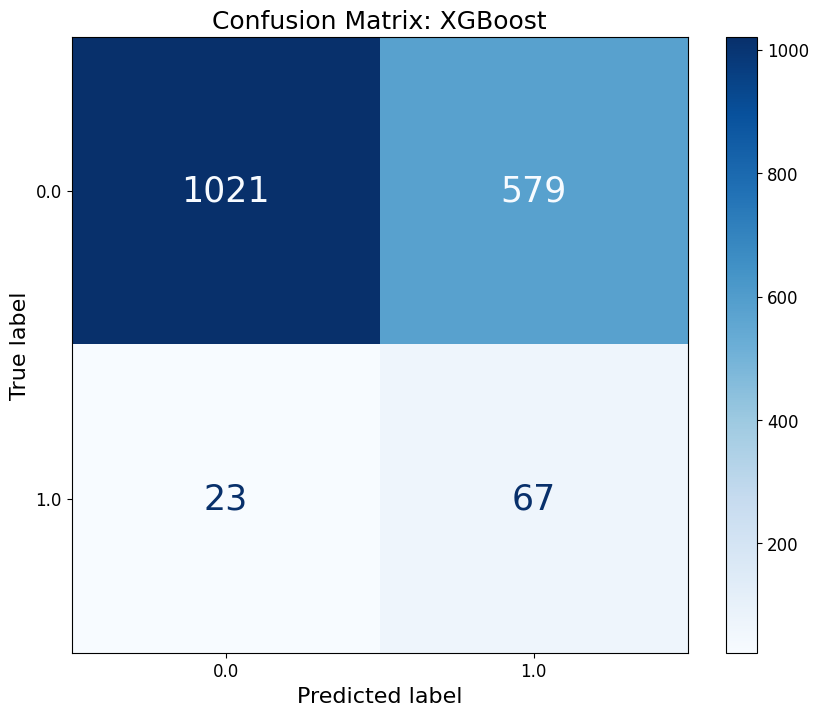

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Set global font sizes for all plot elements
plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=16)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels

y_pred = winner.predict(x_test)

print("--- Final Model Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')

# Increase font size of the numbers inside the matrix cells
for labels in disp.text_.ravel():
    labels.set_fontsize(25)

plt.title('Confusion Matrix: XGBoost')
plt.show()

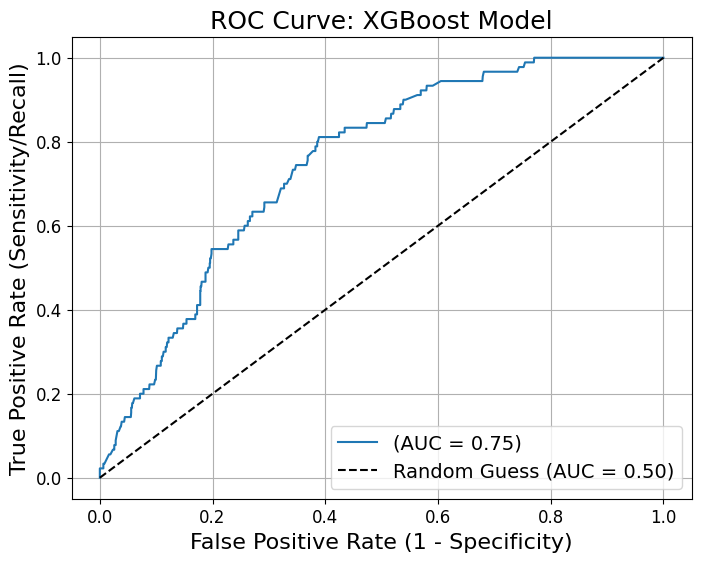

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# We use probabilities for the ROC curve
y_probs = winner.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'(AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('ROC Curve: XGBoost Model')
plt.legend()
plt.grid(True)
plt.show()

# NLP Analysis

## Import Libraries

In [ ]:
from google.colab import files
from google.colab import drive

In [ ]:
!pip install -q contractions nltk gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import warnings
import os
import io
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

In [ ]:
# Import the necessary libraries for text preprocessing
import contractions
import re
from datetime import datetime

# Import NLTK (Natural Language Toolkit) for text tokenization
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

# Import the 'stopwords' corpus from NLTK (Natural Language Toolkit)
from nltk.corpus import stopwords
nltk.download('stopwords')

# WordCloud for visualizing the frequency of words in text data
from wordcloud import WordCloud

# Libraries for lemmatization (reducing words to their base form)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

# Libraries for word embeddings (vector representations of words)
import gensim.downloader as api
import numpy as np

# package to handle warnings
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## Import Data

In [ ]:
#Use this if you are running the code on Colab
from google.colab import files
import io

uploaded = files.upload()

# Read the dataset into a Pandas DataFrame
data = pd.read_csv(io.BytesIO(uploaded['MLPapers.csv']), encoding='ISO-8859-1')

# Select specific columns ('Title', 'Authors', 'Create Date', 'Abstract', "Discussion") from the DataFrame
data = data[['Title', 'Authors', 'Create Date', 'Abstract', "Discussion", "tiabd"]]

# Display the first few rows (head) of the DataFrame to inspect the data
data.head()

Saving MLPapers.csv to MLPapers.csv


,Title,Authors,Create Date,Abstract,Discussion,tiabd
0,Machine learning-based marker for coronary art...,"Forrest IS, Petrazzini BO, Duffy Ã, Park JK, ...",2022-12-23,BACKGROUND: Binary diagnosis of coronary arter...,"Here, we sought to evaluate the performance of...",Machine learning-based marker for coronary art...
1,A Machine Learning Model Using Cardiac CT and ...,"Pezel T, Toupin S, Bousson V, Hamzi K, Hovasse...",2025-01-14,Background Multimodality imaging is essential ...,In a large registry of consecutive patients wi...,A Machine Learning Model Using Cardiac CT and ...
2,Machine Learning Approach on High Risk Treadmi...,"Yilmaz A, HayÄ±roÄlu MÄ°, Salturk S, Pay L, D...",2022-11-06,Treadmill Exercise Test (TET) results and pati...,"Using time and amplitude features of the P, QR...",Machine Learning Approach on High Risk Treadmi...
3,Machine learning-based coronary artery disease...,"Alizadehsani R, Abdar M, Roshanzamir M, Khosra...",2019-07-10,Coronary artery disease (CAD) is the most comm...,"In this section, we not only listed the papers...",Machine learning-based coronary artery disease...
4,A machine-learning based bio-psycho-social mod...,"Raparelli V, Romiti GF, Di Teodoro G, Seccia R...",2023-04-02,BACKGROUND: Mechanisms of myocardial ischemia ...,"In the present study, we developed an interpre...",A machine-learning based bio-psycho-social mod...


In [ ]:
# Import dataset

dir = "/content/drive/My Drive/HAD5016 Course Project"  # <-- change to your folder

filename = "MLPapers.csv"  # <-- confirm the file name
in_path = os.path.join(dir, filename)

data.head()

,Title,Authors,Create Date,Abstract,Discussion,tiabd
0,Machine learning-based marker for coronary art...,"Forrest IS, Petrazzini BO, Duffy Ã, Park JK, ...",2022-12-23,BACKGROUND: Binary diagnosis of coronary arter...,"Here, we sought to evaluate the performance of...",Machine learning-based marker for coronary art...
1,A Machine Learning Model Using Cardiac CT and ...,"Pezel T, Toupin S, Bousson V, Hamzi K, Hovasse...",2025-01-14,Background Multimodality imaging is essential ...,In a large registry of consecutive patients wi...,A Machine Learning Model Using Cardiac CT and ...
2,Machine Learning Approach on High Risk Treadmi...,"Yilmaz A, HayÄ±roÄlu MÄ°, Salturk S, Pay L, D...",2022-11-06,Treadmill Exercise Test (TET) results and pati...,"Using time and amplitude features of the P, QR...",Machine Learning Approach on High Risk Treadmi...
3,Machine learning-based coronary artery disease...,"Alizadehsani R, Abdar M, Roshanzamir M, Khosra...",2019-07-10,Coronary artery disease (CAD) is the most comm...,"In this section, we not only listed the papers...",Machine learning-based coronary artery disease...
4,A machine-learning based bio-psycho-social mod...,"Raparelli V, Romiti GF, Di Teodoro G, Seccia R...",2023-04-02,BACKGROUND: Mechanisms of myocardial ischemia ...,"In the present study, we developed an interpre...",A machine-learning based bio-psycho-social mod...


In [ ]:
df = data.copy()

## Text Pre-Processing

In [ ]:
# Define a cleaning function that will replace the incorrectly encoded characters.
def clean_encoding(text):
    # Replace the incorrect character sequences with the correct character.
    # You can chain multiple replace calls to handle different cases.
    text = text.replace('¡¯', "'")  # Replace the sequence that represents a single quote
    # Add additional replacements here if there are other encoding issues
    #return text

# Apply the cleaning function to the 'tiabd' column of the DataFrame.
df['tiabd_cleaned'] = df['tiabd'].apply(clean_encoding)
df.head()

##don't need to use this because there are no encoding issues in the dataset

,Title,Authors,Create Date,Abstract,Discussion,tiabd,tiabd_cleaned
0,Machine learning-based marker for coronary art...,"Forrest IS, Petrazzini BO, Duffy Ã, Park JK, ...",2022-12-23,BACKGROUND: Binary diagnosis of coronary arter...,"Here, we sought to evaluate the performance of...",Machine learning-based marker for coronary art...,None
1,A Machine Learning Model Using Cardiac CT and ...,"Pezel T, Toupin S, Bousson V, Hamzi K, Hovasse...",2025-01-14,Background Multimodality imaging is essential ...,In a large registry of consecutive patients wi...,A Machine Learning Model Using Cardiac CT and ...,None
2,Machine Learning Approach on High Risk Treadmi...,"Yilmaz A, HayÄ±roÄlu MÄ°, Salturk S, Pay L, D...",2022-11-06,Treadmill Exercise Test (TET) results and pati...,"Using time and amplitude features of the P, QR...",Machine Learning Approach on High Risk Treadmi...,None
3,Machine learning-based coronary artery disease...,"Alizadehsani R, Abdar M, Roshanzamir M, Khosra...",2019-07-10,Coronary artery disease (CAD) is the most comm...,"In this section, we not only listed the papers...",Machine learning-based coronary artery disease...,None
4,A machine-learning based bio-psycho-social mod...,"Raparelli V, Romiti GF, Di Teodoro G, Seccia R...",2023-04-02,BACKGROUND: Mechanisms of myocardial ischemia ...,"In the present study, we developed an interpre...",A machine-learning based bio-psycho-social mod...,None


In [ ]:
# Expand contractions in the 'tiabd' column
df['expanded_tiabd'] = df['tiabd'].apply(lambda x: contractions.fix(x))
df.head()

,Title,Authors,Create Date,Abstract,Discussion,tiabd,tiabd_cleaned,expanded_tiabd
0,Machine learning-based marker for coronary art...,"Forrest IS, Petrazzini BO, Duffy Ã, Park JK, ...",2022-12-23,BACKGROUND: Binary diagnosis of coronary arter...,"Here, we sought to evaluate the performance of...",Machine learning-based marker for coronary art...,None,Machine learning-based marker for coronary art...
1,A Machine Learning Model Using Cardiac CT and ...,"Pezel T, Toupin S, Bousson V, Hamzi K, Hovasse...",2025-01-14,Background Multimodality imaging is essential ...,In a large registry of consecutive patients wi...,A Machine Learning Model Using Cardiac CT and ...,None,A Machine Learning Model Using Cardiac CT and ...
2,Machine Learning Approach on High Risk Treadmi...,"Yilmaz A, HayÄ±roÄlu MÄ°, Salturk S, Pay L, D...",2022-11-06,Treadmill Exercise Test (TET) results and pati...,"Using time and amplitude features of the P, QR...",Machine Learning Approach on High Risk Treadmi...,None,Machine Learning Approach on High Risk Treadmi...
3,Machine learning-based coronary artery disease...,"Alizadehsani R, Abdar M, Roshanzamir M, Khosra...",2019-07-10,Coronary artery disease (CAD) is the most comm...,"In this section, we not only listed the papers...",Machine learning-based coronary artery disease...,None,Machine learning-based coronary artery disease...
4,A machine-learning based bio-psycho-social mod...,"Raparelli V, Romiti GF, Di Teodoro G, Seccia R...",2023-04-02,BACKGROUND: Mechanisms of myocardial ischemia ...,"In the present study, we developed an interpre...",A machine-learning based bio-psycho-social mod...,None,A machine-learning based bio-psycho-social mod...


In [ ]:
# Let's perform some basic data cleaning tasks such as:
# - Converting the date column to datetime
# - Lowercasing the tweet texts
# - Removing URLs
# - Removing Twitter handles
# - Removing special characters and numbers
# - Correcting the spelling of "Neutral" in Emotion column

# Function to remove URLs
def remove_url(text):
    return re.sub(r'http\S+', '', text)

# Function to remove Twitter handles
def remove_handle(text):
    return re.sub(r'@\w+', '', text)

# Function to remove special characters and numbers
def remove_special_characters(text):
    return re.sub(r'[^A-Za-z\s]', '', text)

# Perform the data cleaning
df['tiabd_'] = df['expanded_tiabd'].str.lower()
df['tiabd_'] = df['tiabd_'].apply(remove_url)
df['tiabd_'] = df['tiabd_'].apply(remove_handle)
df['tiabd_'] = df['tiabd_'].apply(remove_special_characters)

df.head()

,Title,Authors,Create Date,Abstract,Discussion,tiabd,tiabd_cleaned,expanded_tiabd,tiabd_
0,Machine learning-based marker for coronary art...,"Forrest IS, Petrazzini BO, Duffy Ã, Park JK, ...",2022-12-23,BACKGROUND: Binary diagnosis of coronary arter...,"Here, we sought to evaluate the performance of...",Machine learning-based marker for coronary art...,None,Machine learning-based marker for coronary art...,machine learningbased marker for coronary arte...
1,A Machine Learning Model Using Cardiac CT and ...,"Pezel T, Toupin S, Bousson V, Hamzi K, Hovasse...",2025-01-14,Background Multimodality imaging is essential ...,In a large registry of consecutive patients wi...,A Machine Learning Model Using Cardiac CT and ...,None,A Machine Learning Model Using Cardiac CT and ...,a machine learning model using cardiac ct and ...
2,Machine Learning Approach on High Risk Treadmi...,"Yilmaz A, HayÄ±roÄlu MÄ°, Salturk S, Pay L, D...",2022-11-06,Treadmill Exercise Test (TET) results and pati...,"Using time and amplitude features of the P, QR...",Machine Learning Approach on High Risk Treadmi...,None,Machine Learning Approach on High Risk Treadmi...,machine learning approach on high risk treadmi...
3,Machine learning-based coronary artery disease...,"Alizadehsani R, Abdar M, Roshanzamir M, Khosra...",2019-07-10,Coronary artery disease (CAD) is the most comm...,"In this section, we not only listed the papers...",Machine learning-based coronary artery disease...,None,Machine learning-based coronary artery disease...,machine learningbased coronary artery disease ...
4,A machine-learning based bio-psycho-social mod...,"Raparelli V, Romiti GF, Di Teodoro G, Seccia R...",2023-04-02,BACKGROUND: Mechanisms of myocardial ischemia ...,"In the present study, we developed an interpre...",A machine-learning based bio-psycho-social mod...,None,A machine-learning based bio-psycho-social mod...,a machinelearning based biopsychosocial model ...


## Tokenization

In [ ]:
def tokenize_text(text):
   return word_tokenize(text)

In [ ]:
df['tokens'] = df['tiabd_'].apply(tokenize_text)
df.head()

,Title,Authors,Create Date,Abstract,Discussion,tiabd,tiabd_cleaned,expanded_tiabd,tiabd_,tokens
0,Machine learning-based marker for coronary art...,"Forrest IS, Petrazzini BO, Duffy Ã, Park JK, ...",2022-12-23,BACKGROUND: Binary diagnosis of coronary arter...,"Here, we sought to evaluate the performance of...",Machine learning-based marker for coronary art...,None,Machine learning-based marker for coronary art...,machine learningbased marker for coronary arte...,"[machine, learningbased, marker, for, coronary..."
1,A Machine Learning Model Using Cardiac CT and ...,"Pezel T, Toupin S, Bousson V, Hamzi K, Hovasse...",2025-01-14,Background Multimodality imaging is essential ...,In a large registry of consecutive patients wi...,A Machine Learning Model Using Cardiac CT and ...,None,A Machine Learning Model Using Cardiac CT and ...,a machine learning model using cardiac ct and ...,"[a, machine, learning, model, using, cardiac, ..."
2,Machine Learning Approach on High Risk Treadmi...,"Yilmaz A, HayÄ±roÄlu MÄ°, Salturk S, Pay L, D...",2022-11-06,Treadmill Exercise Test (TET) results and pati...,"Using time and amplitude features of the P, QR...",Machine Learning Approach on High Risk Treadmi...,None,Machine Learning Approach on High Risk Treadmi...,machine learning approach on high risk treadmi...,"[machine, learning, approach, on, high, risk, ..."
3,Machine learning-based coronary artery disease...,"Alizadehsani R, Abdar M, Roshanzamir M, Khosra...",2019-07-10,Coronary artery disease (CAD) is the most comm...,"In this section, we not only listed the papers...",Machine learning-based coronary artery disease...,None,Machine learning-based coronary artery disease...,machine learningbased coronary artery disease ...,"[machine, learningbased, coronary, artery, dis..."
4,A machine-learning based bio-psycho-social mod...,"Raparelli V, Romiti GF, Di Teodoro G, Seccia R...",2023-04-02,BACKGROUND: Mechanisms of myocardial ischemia ...,"In the present study, we developed an interpre...",A machine-learning based bio-psycho-social mod...,None,A machine-learning based bio-psycho-social mod...,a machinelearning based biopsychosocial model ...,"[a, machinelearning, based, biopsychosocial, m..."


### StopWords

In [ ]:
# Define a function that removes stop words from a list of tokens.
# Stop words are common words that are usually filtered out in NLP tasks.
def remove_stop_words(tokens):
    # Create a set of English stop words. Sets are faster for membership tests than lists.
    stop_words_set = set(stopwords.words('english'))

    # Return a new list that contains only the tokens that are not stop words.
    # The token is also converted to lowercase to ensure case-insensitive matching.
    return [token for token in tokens if token.lower() not in stop_words_set]

# Apply the 'remove_stop_words' function to the 'tokens' column of the dataframe 'df'.
# The result is a new column 'tokens_no_stop' in the dataframe 'df'.
df['tokens_no_stop'] = df['tokens'].apply(remove_stop_words)

# Display the first few rows of the DataFrame showing the 'tweet', 'tokens', and 'tokens_no_stop' columns.
# This gives a visual comparison between the original tokens and the tokens after stop words removal.
df[['tiabd_', 'tokens', 'tokens_no_stop']].head()

,tiabd_,tokens,tokens_no_stop
0,machine learningbased marker for coronary arte...,"[machine, learningbased, marker, for, coronary...","[machine, learningbased, marker, coronary, art..."
1,a machine learning model using cardiac ct and ...,"[a, machine, learning, model, using, cardiac, ...","[machine, learning, model, using, cardiac, ct,..."
2,machine learning approach on high risk treadmi...,"[machine, learning, approach, on, high, risk, ...","[machine, learning, approach, high, risk, trea..."
3,machine learningbased coronary artery disease ...,"[machine, learningbased, coronary, artery, dis...","[machine, learningbased, coronary, artery, dis..."
4,a machinelearning based biopsychosocial model ...,"[a, machinelearning, based, biopsychosocial, m...","[machinelearning, based, biopsychosocial, mode..."


In [ ]:
# Define additional context-sensitive stop words (remove words related to AI/ML/Cardiac/Bias)
context_sensitive_stop_words = set(['machine', 'learning', 'learningbased', 'model', 'approach',
                                    'coronary', 'artery', 'disease', 'based', 'cardiac', 'cad', 'models',
                                    'ml', 'algorithm', 'prediction', 'data', 'ecg', 'dataset', 'study',
                                    'method', 'heart', 'xgboost', 'study', 'analysis', 'may', 'algorithms',
                                    'patient', 'clinical', 'risk', 'high', 'predict', 'patients', 'datasets',
                                    'study', 'result', 'use', 'factor', 'using', 'used', 'method', 'might',
                                    'analysis', 'data', 'research', 'provide', 'shown', 'also',
                                    'performance', 'different', 'significant', 'associated', 'two',
                                    'total', 'within', 'including', 'however', 'reported', 'well'
                                    'study', 'result', 'method', 'factor', 'feature', 'use', 'used',
                                    'using', 'analysis', 'finding', 'performance', 'different',
                                    'associated', 'provide', 'shown', 'significant', 'level', 'factor',
                                    'increase', 'ccta', 'test', 'identify', 'cardiovascular', 'perform',
                                    'test', 'obstructive', 'increase', 'test', 'perform', 'low', 'high', 'level',
                                    'potential', 'large', 'present', 'application', 'individual', 'medical', 'score',
                                    'variable', 'diagnostic', 'task', 'process', 'participant', 'cohort', 'ct',
                                    'increase', 'increased', 'increasing', 'result', 'show', 'shown', 'technique',
                                    'demonstrate', 'demonstrated', 'evaluate', 'evaluated', 'identify',
                                    'identified', 'significant', 'significantly', 'perform', 'performed',
                                    'compare', 'compared', 'suggest', 'suggested', 'report', 'reported',
                                    'associated', 'association', 'various', 'among', 'across', 'inclusion'])

# English stop words
stop_words_set = set(stopwords.words('english')) # At the beginning of the tutorial, we downloaded a predefined set of common stopwords from NLTK /
# in this line, we're getting this predefined set of english stop words.

# Here we will remove both general and context-sensitive stop words
def remove_context_sensitive_stop_words(tokens):
    # Combine the general English stop words with the context-specific stop words /
    # to create a comprehensive set of words to filter out.
    all_stop_words = stop_words_set | context_sensitive_stop_words
    return [token for token in tokens if token.lower() not in all_stop_words]

# Apply the updated function to remove both general and context-sensitive stop words
df['tokens_no_stop_context'] = df['tokens'].apply(remove_context_sensitive_stop_words)

# Display the DataFrame
df[['tiabd_', 'tokens', 'tokens_no_stop_context']].head()


,tiabd_,tokens,tokens_no_stop_context
0,machine learningbased marker for coronary arte...,"[machine, learningbased, marker, for, coronary...","[marker, derivation, validation, longitudinal,..."
1,a machine learning model using cardiac ct and ...,"[a, machine, learning, model, using, cardiac, ...","[mri, predicts, events, background, multimodal..."
2,machine learning approach on high risk treadmi...,"[machine, learning, approach, on, high, risk, ...","[treadmill, exercise, p, qrs, waves, features,..."
3,machine learningbased coronary artery disease ...,"[machine, learningbased, coronary, artery, dis...","[diagnosis, comprehensive, review, common, cvd..."
4,a machinelearning based biopsychosocial model ...,"[a, machinelearning, based, biopsychosocial, m...","[machinelearning, biopsychosocial, nonobstruct..."




## Lemmatization

In [ ]:
# Function to map NLTK position tags to WordNet tags
def get_wordnet_pos(word, pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# Instantiate the lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to lemmatize a list of tokens with POS tags
def lemmatize_tokens_with_pos(tokens):
    tagged_tokens = nltk.pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(word, tag)) for word, tag in tagged_tokens]

# Apply this function to the 'tokens' column
df['lemmatized'] = df['tokens_no_stop_context'].apply(lemmatize_tokens_with_pos)

In [ ]:
# Apply the updated function to remove both general and context-sensitive stop words
df['lemmatized_no_stop_context'] = df['lemmatized'].apply(remove_context_sensitive_stop_words)

In [ ]:
# Display the DataFrame
df[['tiabd', 'tokens_no_stop_context', 'lemmatized', 'lemmatized_no_stop_context']].head()

,tiabd,tokens_no_stop_context,lemmatized,lemmatized_no_stop_context
0,Machine learning-based marker for coronary art...,"[marker, derivation, validation, longitudinal,...","[marker, derivation, validation, longitudinal,...","[marker, derivation, validation, longitudinal,..."
1,A Machine Learning Model Using Cardiac CT and ...,"[mri, predicts, events, background, multimodal...","[mri, predict, event, background, multimodalit...","[mri, event, background, multimodality, image,..."
2,Machine Learning Approach on High Risk Treadmi...,"[treadmill, exercise, p, qrs, waves, features,...","[treadmill, exercise, p, qrs, wave, feature, t...","[treadmill, exercise, p, qrs, wave, treadmill,..."
3,Machine learning-based coronary artery disease...,"[diagnosis, comprehensive, review, common, cvd...","[diagnosis, comprehensive, review, common, cvd...","[diagnosis, comprehensive, review, common, cvd..."
4,A machine-learning based bio-psycho-social mod...,"[machinelearning, biopsychosocial, nonobstruct...","[machinelearning, biopsychosocial, nonobstruct...","[machinelearning, biopsychosocial, nonobstruct..."


## Visualization - Lemmatized

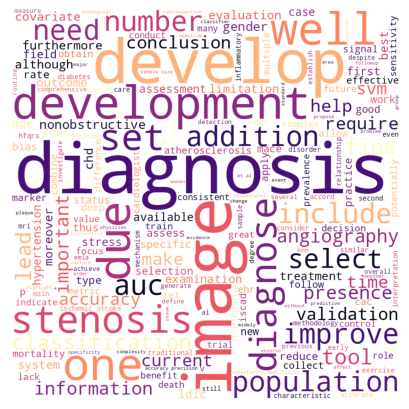

In [ ]:
# Combine all tokens from the 'lemmatized' column into a single list
all_tokens = sum(df['lemmatized_no_stop_context'].head(5000).tolist(), [])

# Create a text string required by WordCloud
text = ' '.join(all_tokens)

# Create a WordCloud object
wordcloud = WordCloud(width = 800, height = 800,
                      background_color ='white',
                      colormap='magma',  # Use the 'magma' colormap
                      min_font_size = 10).generate(text)

# Plot the WordCloud image
plt.figure(figsize = (3.9, 3.9), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()